🎯 **You Sank My Function** — Black-Box Optimisation Capstone · Imperial College Business School

**Weekly pipeline** · [04 Consolidate](../pipeline/04_consolidate_data.ipynb) → [05b Suggest Engine v2](05b_suggest_engine_v2.ipynb) → **07 Ceiling Estimator** → [06 Diagnose](../pipeline/06_diagnose.ipynb)

> 📍 **This notebook** — estimates the **maximum predicted value (the ceiling)** of each of the
> eight functions, with uncertainty bands and a visual demonstration of the evidence behind each
> estimate. The ceiling is not a curiosity: the scoring rule is
> `score = (best-ever − initial-best) / (true-max − initial-best)`,
> so the ceiling estimate is literally the denominator of the grade — it tells you where the
> remaining headroom lives and which functions still deserve probes.

---

# 07 · Predicted-Maximum (Ceiling) Estimator
### One estimator per pathology, one uncertainty band per function

| archetype | ceiling estimator | uncertainty band |
|---|---|---|
| `needle` (F1) | log-quadratic vertex **value** through the top-3 near-peak points | residual of the wider 4–6-point fit, back-transformed |
| `stochastic_capped` (F2, F3) | max of the GP **latent mean** (noise fixed at the measured sd) | + expected best of the remaining lucky draws, `E[max of W N(0,σ)]` |
| `local_peak` (F4, F6) | median of {local 1-D quadratic vertex, geometric-convergence asymptote, GP trust-region mean-max}, floored at best-ever | [best-ever, GP trust-region UCB] |
| `boundary_climb` (F5) | best-ever + on-line marginal gradient × plausible vertex distance | [best-ever, extrapolation cap] |
| `solved_lock` (F7, F8) | best-ever (analytic identity) | zero |

A pathology-blind **global GP-UCB** column is kept as the naive reference — the gap between it and
the pathology-aware estimate is the same gap the suggest engine exploits.

## 0 · Configuration & data

In [1]:
import warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, spearmanr
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
warnings.filterwarnings("ignore")

CONSOLIDATED = "consolidated_observations.csv"
SEED = 42
OBS  = pd.read_csv(CONSOLIDATED)
DIMS = OBS.groupby("function").dim.first().to_dict()
N_WEEKS = int(OBS.week.max())

LOCK_PRIOR = (7, 8)                 # analytic identities (human knowledge)
STRUCTURAL_UPPER = {3: 0.0}         # known hard upper bounds (F3: transformed side-effect score, sup <= 0)
REMAINING_WEEKS = 5                 # probes left -> sizes the "lucky draw" allowance on noisy functions

def xy(fid):
    sub = OBS[OBS.function == fid]; d = DIMS[fid]
    return sub[[f"x{i+1}" for i in range(d)]].to_numpy(float), sub["y"].to_numpy(float), sub

def best_so_far(fid):
    _, _, sub = xy(fid)
    weeks = sorted(sub.week.unique())
    return weeks, [sub[sub.week <= w].y.max() for w in weeks]

INIT_BEST = {f: OBS[(OBS.function == f) & (OBS.week == 0)].y.max() for f in range(1, 9)}
print(f"Loaded {len(OBS)} observations · weeks 0–{N_WEEKS}")
print("Initial bests:", {f: f"{v:.4g}" for f, v in INIT_BEST.items()})

Loaded 279 observations · weeks 0–13
Initial bests: {1: '7.711e-16', 2: '0.6112', 3: '-0.03484', 4: '-4.026', 5: '1089', 6: '-0.7143', 7: '1.365', 8: '9.598'}


## 1 · Pathology classifier (same router as 05b)

The ceiling method must match the landscape, for the same reason the probe method must: a global
surrogate averages the needle away and hallucinates headroom on the casino table.

In [2]:
def sig_noise(fid):
    X, y, _ = xy(fid); pairs = []
    for i in range(len(X)):
        for j in range(i+1, len(X)):
            if np.linalg.norm(X[i]-X[j]) < 0.01:
                pairs.append(abs(y[i]-y[j]))
    if pairs:
        return float(np.median(pairs)/np.sqrt(2)), "near-exact resamples"
    k = C(1.0)*Matern(0.2, nu=2.5) + WhiteKernel(1e-3, (1e-12, 1e2))
    gp = GaussianProcessRegressor(kernel=k, normalize_y=True,
                                  n_restarts_optimizer=2, random_state=SEED).fit(X, y)
    return float(np.sqrt(gp.kernel_.k2.noise_level)*np.std(y)), "GP WhiteKernel"

def classify(fid):
    if fid in LOCK_PRIOR:
        return "solved_lock", ["analytic identity confirmed (human prior)"]
    X, y, sub = xy(fid); d = DIMS[fid]
    ay = np.abs(y); eps = 1e-300
    decades = np.log10(ay.max()+eps) - np.log10(np.median(ay)+eps)
    if decades >= 6 and np.mean(ay < 0.01*ay.max()) >= 0.5:
        return "needle", [f"magnitude cascade {decades:.0f} decades"]
    i_best = int(np.argmax(y)); best_week = int(sub.iloc[i_best]["week"])
    at_bound = int(np.sum((X[i_best] < .03) | (X[i_best] > .97)))
    rhos = [abs(spearmanr(X[:, j], y)[0] or 0) for j in range(d)]
    if at_bound >= d-1 and np.mean(rhos) > .4 and y.max() > 10*abs(np.median(y)):
        return "boundary_climb", [f"{at_bound}/{d} coords at bounds, monotone huge range"]
    noise, src = sig_noise(fid)
    if noise > 0 and best_week <= 1:
        near = [yy for xx, yy in zip(X, y)
                if np.linalg.norm(xx - X[i_best]) < 0.08 and yy < y.max()]
        if len(near) >= 2 and np.mean(near) < y.max() - noise:
            return "stochastic_capped", [f"winner's-curse best (week {best_week}); noise sd {noise:.3g} ({src})"]
    return "local_peak", ["climbing / local structure"]

## 2 · Ceiling estimator library

Every estimator returns `(low, central, high, method, extras)` with `low = best-ever` always —
the ceiling can never be below a value already banked. `extras` carries whatever the visual
gallery needs to *show* the evidence.

In [3]:
def line_fit(Xt, vt, origin):
    """Weighted PCA line through points + 1-D quadratic of vt against position t."""
    w = vt - vt.min() + 1e-9; w /= w.sum()
    Xc = (Xt - (Xt*w[:, None]).sum(0)) * np.sqrt(w)[:, None]
    u = np.linalg.svd(Xc, full_matrices=False)[2][0]
    t = (Xt - origin) @ u
    A = np.column_stack([np.ones_like(t), t, t**2])
    coef, *_ = np.linalg.lstsq(A, vt, rcond=None)
    resid = float(np.sqrt(np.mean((A@coef - vt)**2)))
    return coef, resid, t, u

def ceil_needle(fid):
    X, y, _ = xy(fid); inc = X[np.argmax(y)]; best = y.max()
    idx3 = np.argsort(y)[-3:]                                   # exact fit through top-3
    coef, _, t3, u = line_fit(X[idx3], np.log(y[idx3]), inc)
    ts = -coef[1]/(2*coef[2])
    central = float(np.exp(coef[0] + coef[1]*ts + coef[2]*ts**2))
    pos = np.where(y > 0)[0]                                    # wider fit -> honest band
    lt = np.log(y[pos] + 1e-300)
    sel = pos[lt >= lt.max() - 5]
    _, resid, _, _ = line_fit(X[sel], np.log(y[sel]), inc)
    central = max(central, best)
    return best, central, max(central*np.exp(2*resid), central), \
           f"log-quadratic vertex value (top-3 pts, curvature a={coef[2]:.0f}, t*={ts:+.4f})", \
           dict(coef=coef, t=t3, u=u, inc=inc)

def _fit_capped_gp(fid, noise):
    X, y, _ = xy(fid)
    k = C(1.0)*Matern(0.2, nu=2.5, length_scale_bounds=(0.05, 2.0)) \
        + WhiteKernel(max(noise, 1e-6)**2, "fixed")
    return GaussianProcessRegressor(kernel=k, normalize_y=True,
                                    n_restarts_optimizer=3, random_state=SEED).fit(X, y)

def e_max_gauss(n):
    """E[max of n iid N(0,1)] by quick Monte Carlo."""
    rng = np.random.default_rng(0)
    return float(rng.normal(size=(200_000, n)).max(axis=1).mean()) if n >= 1 else 0.0

def ceil_stochastic(fid):
    X, y, _ = xy(fid); d = DIMS[fid]; best = y.max()
    noise, src = sig_noise(fid)
    gp = _fit_capped_gp(fid, noise)
    rng = np.random.default_rng(SEED + fid)
    cand = np.vstack([rng.uniform(0, 1, (8000, d)),
                      np.clip(X + rng.normal(0, 0.03, X.shape), 0, 1)])
    mu = gp.predict(cand)
    mu_max = float(mu.max())
    lucky = e_max_gauss(REMAINING_WEEKS) * noise
    central, high = mu_max, mu_max + lucky
    cap = STRUCTURAL_UPPER.get(fid)
    note = ""
    if cap is not None:
        central, high = min(central, cap), min(high, cap)
        note = f"; capped by structural bound sup<={cap}"
    central = max(central, best); high = max(high, central)
    return best, central, high, \
           f"GP latent-mean max {mu_max:.4g} + lucky-draw allowance " \
           f"E[max of {REMAINING_WEEKS} draws]*sd={lucky:.3g} (noise {noise:.3g}, {src}){note}", \
           dict(gp=gp, noise=noise)

def ceil_local_peak(fid, r=0.2):
    X, y, _ = xy(fid); d = DIMS[fid]; inc = X[np.argmax(y)]; best = y.max()
    cands, tags = [], []
    sel = np.linalg.norm(X - inc, axis=1) < r                   # (a) local 1-D quadratic vertex
    quad = None
    if sel.sum() >= 4:
        coef, resid, t, u = line_fit(X[sel], y[sel], inc)
        if coef[2] < 0:
            ts = -coef[1]/(2*coef[2])
            v = float(coef[0] + coef[1]*ts + coef[2]*ts**2)
            quad = dict(coef=coef, t=t, y=y[sel], resid=resid)
            if v >= best:
                cands.append(v); tags.append(f"local quad vertex {v:.3f}")
    weeks, bsf = best_so_far(fid)                               # (b) geometric-convergence asymptote
    gains = np.diff(bsf); gains = gains[gains > 1e-12]
    geo = None
    if len(gains) >= 2 and gains[-1] < gains[-2]:
        rr = gains[-1]/gains[-2]
        geo = best + gains[-1]*rr/(1-rr)
        cands.append(geo); tags.append(f"geometric asymptote {geo:.3f} (gain ratio {rr:.2f})")
    noise, _ = sig_noise(fid)                                   # (c) GP trust-region mean-max / UCB
    gp = _fit_capped_gp(fid, noise)
    rng = np.random.default_rng(SEED + fid)
    ball = np.clip(inc + rng.normal(0, r/2, (6000, d)), 0, 1)
    ball = ball[np.linalg.norm(ball - inc, axis=1) < r]
    mu, s = gp.predict(ball, return_std=True)
    gp_mean, gp_ucb = float(mu.max()), float((mu + 2*s).max())
    if gp_mean >= best:
        cands.append(gp_mean); tags.append(f"GP TR mean-max {gp_mean:.3f}")
    central = float(np.median(cands)) if cands else best
    high = max(gp_ucb, central)
    return best, max(central, best), high, \
           "median of {" + "; ".join(tags or ["no estimator above best-ever"]) + \
           f"}}; band top = GP TR UCB {gp_ucb:.3f}", \
           dict(quad=quad, geo=geo, bsf=(weeks, bsf), gp_mean=gp_mean)

def ceil_boundary(fid, vertex_dist=0.1):
    X, y, _ = xy(fid); inc = X[np.argmax(y)]; best = y.max(); d = DIMS[fid]
    grads = {}
    for j in range(d):                                          # on-line marginal gradients
        others = np.delete(np.arange(d), j)
        online = np.abs(X[:, others] - inc[others]).max(axis=1) < 1e-9
        vals, ys = X[online, j], y[online]
        if len(vals) >= 2 and vals.max() - vals.min() > 1e-9:
            grads[j] = ((ys.max() - ys.min())/(vals.max() - vals.min()), vals, ys)
    g = max((gg for gg, _, _ in grads.values()), default=0.0)
    central = best + g*vertex_dist/2
    high = best + g*vertex_dist
    return best, central, high, \
           f"on-line marginal gradient {g:.3g}/unit x plausible vertex distance {vertex_dist} " \
           f"(headroom {(high-best)/max(abs(best),1e-12):.2%} of |best|)", \
           dict(grads=grads)

def ceil_solved(fid):
    _, y, _ = xy(fid); best = y.max()
    return best, best, best, "analytic identity — ceiling equals banked optimum", {}

def ceil_gp_ucb_reference(fid):
    """Pathology-blind reference: max of mu+2s over the cube under one global GP."""
    X, y, _ = xy(fid); d = DIMS[fid]
    noise, _ = sig_noise(fid)
    gp = _fit_capped_gp(fid, noise)
    cand = np.random.default_rng(SEED+fid).uniform(0, 1, (8000, d))
    mu, s = gp.predict(cand, return_std=True)
    return float((mu + 2*s).max())

CEILS = dict(needle=ceil_needle, stochastic_capped=ceil_stochastic,
             local_peak=ceil_local_peak, boundary_climb=ceil_boundary,
             solved_lock=ceil_solved)

## 3 · Run all eight — the ceiling table

In [4]:
RES = {}
rows = []
for f in range(1, 9):
    label, ev = classify(f)
    low, central, high, method, extras = CEILS[label](f)
    naive = ceil_gp_ucb_reference(f)
    init = INIT_BEST[f]
    denom = central - init
    attained = float(np.clip((low - init)/denom, 0, 1)) if denom > 1e-12 else 1.0
    RES[f] = dict(label=label, low=low, central=central, high=high,
                  method=method, extras=extras, naive=naive, attained=attained)
    rows.append({"F": f"F{f}", "pathology": label,
                 "initial best": round(init, 4), "best-ever": round(low, 4),
                 "ceiling (central)": round(central, 4), "ceiling (high)": round(high, 4),
                 "naive GP-UCB ref": round(naive, 3),
                 "score attained": f"{attained:.0%}",
                 "headroom": round(central - low, 4), "method": method})
ceiling_table = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 110)
ceiling_table.drop(columns=["method"])

,F,pathology,initial best,best-ever,ceiling (central),ceiling (high),naive GP-UCB ref,score attained,headroom
0,F1,local_peak,0.0000,2.0000,2.1201,3.1863,3.184,94%,0.1202
1,F2,local_peak,0.6112,0.6505,0.6653,0.9748,0.988,73%,0.0148
2,F3,local_peak,-0.0348,-0.0004,-0.0004,0.2285,0.346,100%,0.0000
3,F4,local_peak,-4.0255,0.6549,0.6625,1.4738,1.181,100%,0.0076
4,F5,boundary_climb,1088.8596,8662.4825,9457.0010,10251.5195,8189.734,91%,794.5185
5,F6,local_peak,-0.7143,-0.2347,-0.2341,-0.1241,-0.062,100%,0.0007
6,F7,solved_lock,1.3650,3.3224,3.3224,3.3224,3.914,100%,0.0000
7,F8,solved_lock,9.5985,10.0000,10.0000,10.0000,10.511,100%,0.0000


In [5]:
for f in range(1, 9):
    print(f"F{f} [{RES[f]['label']}] -> {RES[f]['method']}")

F1 [local_peak] -> median of {geometric asymptote 2.000 (gain ratio 0.00); GP TR mean-max 2.240}; band top = GP TR UCB 3.186
F2 [local_peak] -> median of {GP TR mean-max 0.665}; band top = GP TR UCB 0.975
F3 [local_peak] -> median of {no estimator above best-ever}; band top = GP TR UCB 0.228
F4 [local_peak] -> median of {geometric asymptote 0.662 (gain ratio 0.34)}; band top = GP TR UCB 1.474
F5 [boundary_climb] -> on-line marginal gradient 1.59e+04/unit x plausible vertex distance 0.1 (headroom 18.34% of |best|)
F6 [local_peak] -> median of {geometric asymptote -0.234 (gain ratio 0.15)}; band top = GP TR UCB -0.124
F7 [solved_lock] -> analytic identity — ceiling equals banked optimum
F8 [solved_lock] -> analytic identity — ceiling equals banked optimum


## 4 · Visual demonstration I — the evidence behind each ceiling

One panel per function, showing the *fit that produced the number*: the log-quadratic peak (F1),
the latent ridge mean vs the lucky draw (F2, F3), the local climb and its projected vertex
(F4, F6), the on-line marginal gradient (F5), and the flat lines of the solved pair (F7, F8).

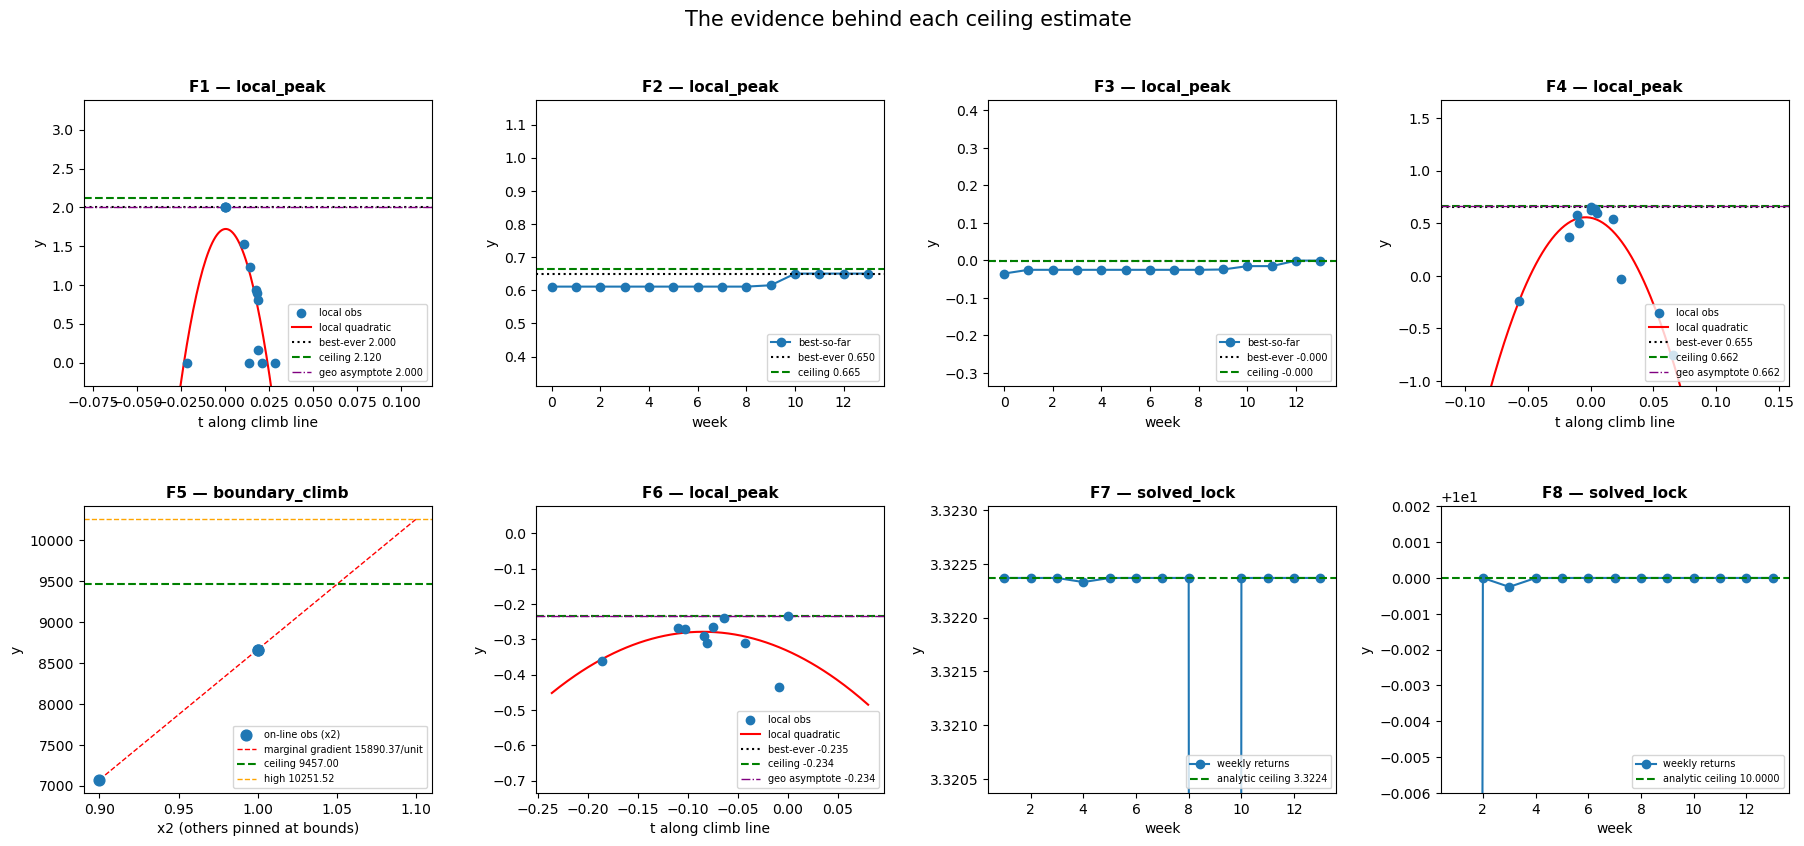

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
plt.subplots_adjust(hspace=0.42, wspace=0.3)

for f, ax in zip(range(1, 9), axes.ravel()):
    r = RES[f]; X, y, sub = xy(f); ex = r["extras"]
    ax.set_title(f"F{f} — {r['label']}", fontsize=11, fontweight="bold")

    if r["label"] == "needle":
        coef, t, u, inc = ex["coef"], ex["t"], ex["u"], ex["inc"]
        pos = y > 0
        tt = (X[pos] - inc) @ u
        ax.scatter(tt, np.log10(y[pos]), c="tab:blue", zorder=3, label="obs (log10 y)")
        tg = np.linspace(min(tt.min(), -0.02), max(tt.max(), 0.02), 200)
        ax.plot(tg, (coef[0] + coef[1]*tg + coef[2]*tg**2)/np.log(10), "r-", lw=1.5,
                label="log-quadratic fit")
        ax.axhline(np.log10(r["central"]), color="g", ls="--", label=f"ceiling {r['central']:.3f}")
        ax.set_xlim(-0.05, 0.03); ax.set_ylim(np.log10(r['central'])-3, 0.4)
        ax.set_xlabel("t along peak line"); ax.set_ylabel("log10 y")

    elif r["label"] == "stochastic_capped":
        gp, noise = ex["gp"], ex["noise"]
        inc = X[np.argmax(y)]
        j = int(np.argmax([abs(spearmanr(X[:, k_], y)[0] or 0) for k_ in range(DIMS[f])]))
        grid = np.linspace(0, 1, 200)
        Xg = np.tile(inc, (200, 1)); Xg[:, j] = grid
        mu, s = gp.predict(Xg, return_std=True)
        ax.plot(grid, mu, "b-", label="GP latent mean (slice)")
        ax.fill_between(grid, mu - 2*noise, mu + 2*noise, alpha=0.15, color="b",
                        label="±2 noise sd")
        ax.scatter(X[:, j], y, c=sub.week, cmap="viridis", s=28, zorder=3, label="obs (by week)")
        ax.axhline(y.max(), color="k", ls=":", label=f"best-ever {y.max():.3f}")
        ax.axhline(r["central"], color="g", ls="--", label=f"ceiling {r['central']:.3f}")
        ax.axhline(r["high"], color="orange", ls="--", lw=1,
                   label=f"+lucky draws {r['high']:.3f}")
        ax.set_xlabel(f"x{j+1} (most active dim, slice at incumbent)"); ax.set_ylabel("y")

    elif r["label"] == "local_peak":
        quad, geo, (weeks, bsf) = ex["quad"], ex["geo"], ex["bsf"]
        if quad is not None:
            t, yy, coef = quad["t"], quad["y"], quad["coef"]
            ax.scatter(t, yy, c="tab:blue", zorder=3, label="local obs")
            tg = np.linspace(t.min()-0.05, t.max()+0.08, 200)
            ax.plot(tg, coef[0] + coef[1]*tg + coef[2]*tg**2, "r-", lw=1.5,
                    label="local quadratic")
            ax.set_xlabel("t along climb line")
        else:
            ax.plot(weeks, bsf, "o-", label="best-so-far")
            ax.set_xlabel("week")
        ax.axhline(y.max(), color="k", ls=":", label=f"best-ever {y.max():.3f}")
        ax.axhline(r["central"], color="g", ls="--", label=f"ceiling {r['central']:.3f}")
        if geo is not None:
            ax.axhline(geo, color="purple", ls="-.", lw=1, label=f"geo asymptote {geo:.3f}")
        ax.set_ylabel("y")
        ax.set_ylim(min(np.min(quad["y"]) if quad else min(bsf), y.max()) - 0.3,
                    max(r["high"], r["central"]) + 0.2)

    elif r["label"] == "boundary_climb":
        grads = ex["grads"]
        j = max(grads, key=lambda k_: grads[k_][0]) if grads else 0
        g, vals, ys = grads[j]
        ax.scatter(vals, ys, c="tab:blue", s=60, zorder=3, label=f"on-line obs (x{j+1})")
        vg = np.linspace(vals.min(), vals.max() + 0.1, 50)
        ax.plot(vg, ys.max() + g*(vg - vals[np.argmax(ys)]), "r--", lw=1,
                label=f"marginal gradient {g:.2f}/unit")
        ax.axhline(r["central"], color="g", ls="--", label=f"ceiling {r['central']:.2f}")
        ax.axhline(r["high"], color="orange", ls="--", lw=1, label=f"high {r['high']:.2f}")
        ax.set_xlabel(f"x{j+1} (others pinned at bounds)"); ax.set_ylabel("y")

    else:  # solved_lock
        wk = sub[sub.week > 0].sort_values("week")
        ax.plot(wk.week, wk.y, "o-", label="weekly returns")
        ax.axhline(r["central"], color="g", ls="--",
                   label=f"analytic ceiling {r['central']:.4f}")
        span = max(abs(r["central"])*1e-4, 1e-6)
        ax.set_ylim(r["central"] - 6*span, r["central"] + 2*span)
        ax.set_xlabel("week"); ax.set_ylabel("y")

    ax.legend(fontsize=7, loc="lower right")

fig.suptitle("The evidence behind each ceiling estimate", fontsize=15, y=0.98)
plt.savefig("ceiling_evidence_gallery.png", dpi=130, bbox_inches="tight")
plt.show()

## 5 · Visual demonstration II — best-so-far vs the ceiling band

The convergence view: how much of each function's headroom has been consumed, week by week.
Solved functions hug their ceiling from the week they were cracked; the casino tables (F2, F3)
show a flat best-so-far *under* a ceiling band that only luck can reach.

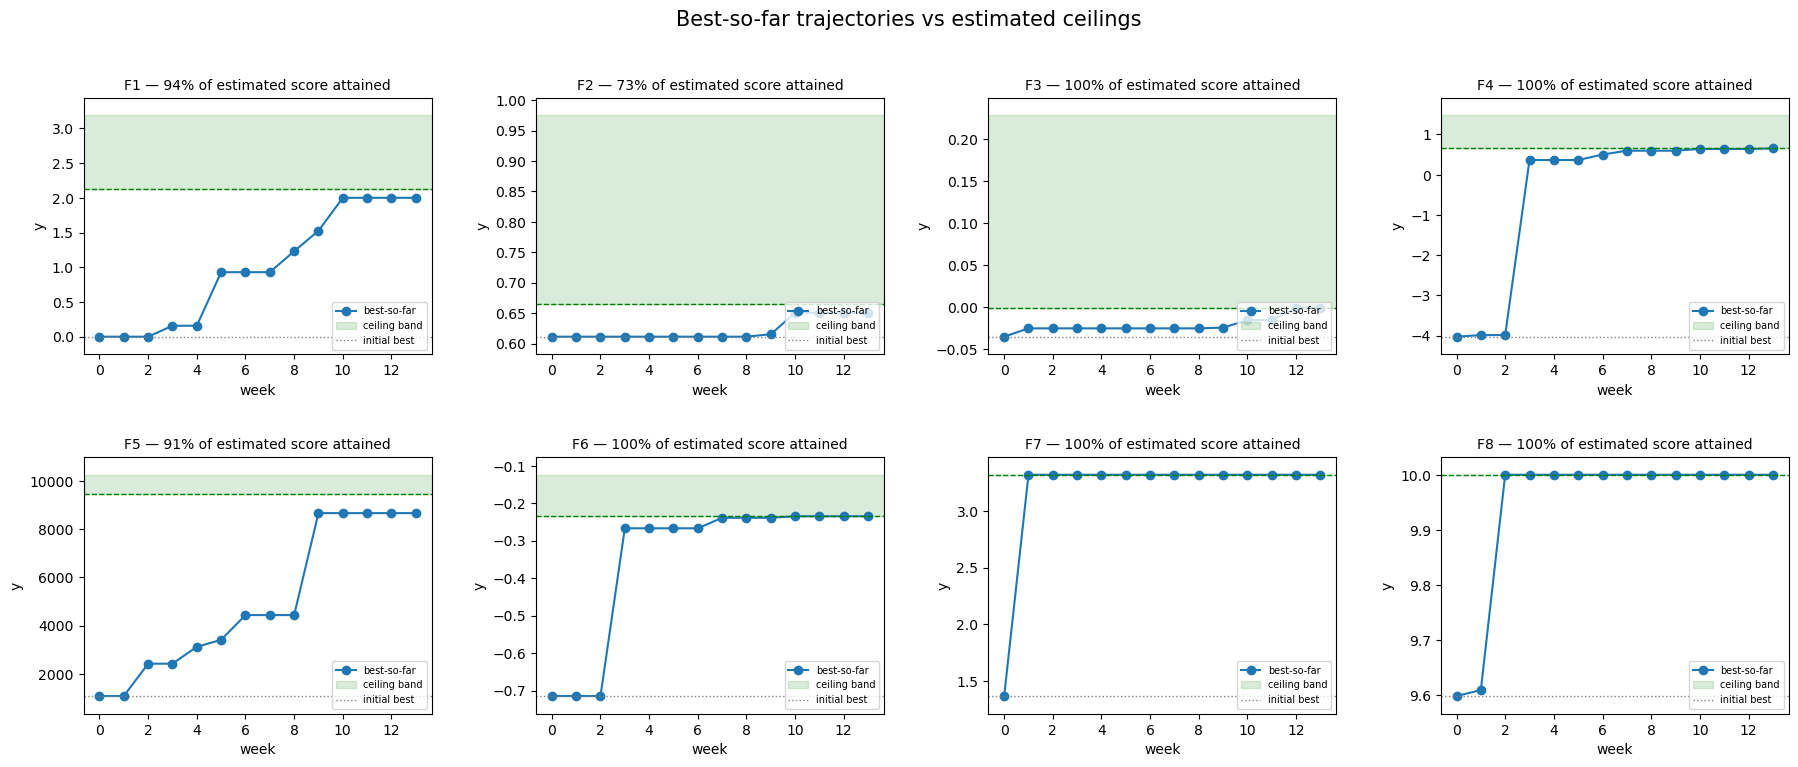

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(22, 8))
plt.subplots_adjust(hspace=0.4, wspace=0.3)
for f, ax in zip(range(1, 9), axes.ravel()):
    r = RES[f]
    weeks, bsf = best_so_far(f)
    ax.plot(weeks, bsf, "o-", color="tab:blue", label="best-so-far")
    ax.axhspan(r["central"], r["high"], color="green", alpha=0.15, label="ceiling band")
    ax.axhline(r["central"], color="green", ls="--", lw=1)
    ax.axhline(INIT_BEST[f], color="gray", ls=":", lw=1, label="initial best")
    ax.set_title(f"F{f} — {r['attained']:.0%} of estimated score attained", fontsize=10)
    ax.set_xlabel("week"); ax.set_ylabel("y")
    lo = min(min(bsf), INIT_BEST[f]); hi = max(r["high"], max(bsf))
    pad = 0.08*(hi - lo) if hi > lo else max(abs(hi)*1e-4, 1e-6)
    ax.set_ylim(lo - pad, hi + pad)
    ax.legend(fontsize=7, loc="lower right")
fig.suptitle("Best-so-far trajectories vs estimated ceilings", fontsize=15, y=0.99)
plt.savefig("ceiling_convergence.png", dpi=130, bbox_inches="tight")
plt.show()

## 6 · Visual demonstration III — where the remaining score lives

Score attained per function under the central ceiling estimate, and the absolute headroom left.
This chart *is* the probe-allocation argument: functions at ~100 % get ε-locks, the rest get the
engine's tickets in proportion to what is still purchasable.

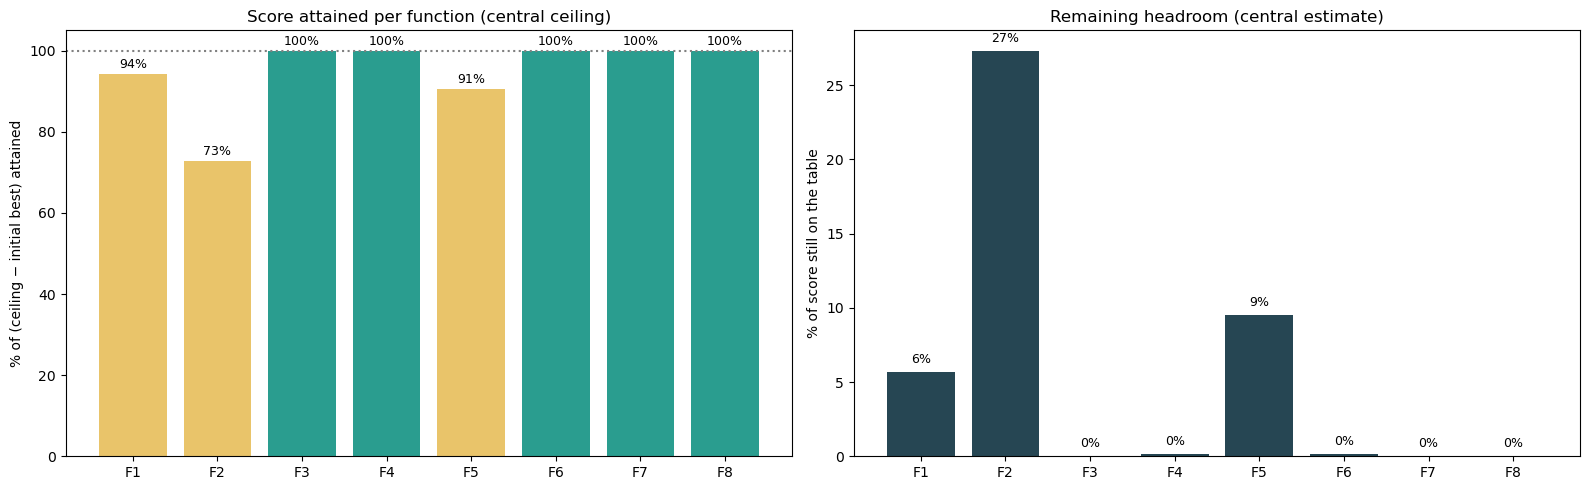

Probe-priority ranking (by remaining score): F2 (27%) > F5 (9%) > F1 (6%)


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fs = [f"F{f}" for f in range(1, 9)]
att = [RES[f]["attained"] for f in range(1, 9)]
colors = ["#2a9d8f" if a >= 0.98 else "#e9c46a" if a >= 0.6 else "#e76f51" for a in att]
ax1.bar(fs, [a*100 for a in att], color=colors)
ax1.axhline(100, color="gray", ls=":")
ax1.set_ylabel("% of (ceiling − initial best) attained")
ax1.set_title("Score attained per function (central ceiling)")
for i, a in enumerate(att):
    ax1.text(i, a*100 + 1.5, f"{a:.0%}", ha="center", fontsize=9)

rel_head = []
for f in range(1, 9):
    r = RES[f]; denom = r["central"] - INIT_BEST[f]
    rel_head.append(100*max(r["central"] - r["low"], 0)/denom if denom > 1e-12 else 0.0)
ax2.bar(fs, rel_head, color="#264653")
ax2.set_ylabel("% of score still on the table")
ax2.set_title("Remaining headroom (central estimate)")
for i, h in enumerate(rel_head):
    ax2.text(i, h + 0.6, f"{h:.0f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("ceiling_headroom.png", dpi=130, bbox_inches="tight")
plt.show()

order = np.argsort(rel_head)[::-1]
print("Probe-priority ranking (by remaining score):",
      " > ".join(fs[i] + f" ({rel_head[i]:.0f}%)" for i in order if rel_head[i] > 0.5) or "nothing material")

## 7 · Export

The ceiling table feeds two places: the **suggest engine** (probe priority = remaining headroom)
and the **final report** (the denominator of the score, stated with its uncertainty instead of
pretended to be known).

In [9]:
ceiling_table.to_csv("ceiling_estimates.csv", index=False)
print("Wrote: ceiling_estimates.csv + ceiling_evidence_gallery.png, "
      "ceiling_convergence.png, ceiling_headroom.png")
print("\nCaveats worth keeping in the report:")
print(" - F4's ceiling is the widest band on the board: the vertex is not yet bracketed above,")
print("   so the geometric asymptote is an extrapolation, not a fit.")
print(" - F2/F3 ceilings are latent-MEAN ceilings; only lucky draws can exceed them, and the")
print("   scoring rule banks lucky draws — hence the separate 'high' line.")
print(" - Naive GP-UCB is reported as the contrast: it hallucinates headroom exactly where the")
print("   pathology-aware estimators say the game is over.")

Wrote: ceiling_estimates.csv + ceiling_evidence_gallery.png, ceiling_convergence.png, ceiling_headroom.png

Caveats worth keeping in the report:
 - F4's ceiling is the widest band on the board: the vertex is not yet bracketed above,
   so the geometric asymptote is an extrapolation, not a fit.
 - F2/F3 ceilings are latent-MEAN ceilings; only lucky draws can exceed them, and the
   scoring rule banks lucky draws — hence the separate 'high' line.
 - Naive GP-UCB is reported as the contrast: it hallucinates headroom exactly where the
   pathology-aware estimators say the game is over.
